In [88]:
# Import the Libraries which are required to work on this project

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
# Load the dataset

df=pd.read_csv(r"C:\Users\KRISHNA\Desktop\datasets\employee_attrition_raw_1L.csv")
df.shape

(100000, 32)

1. How many duplicate EmployeeIDs exist in the dataset? Write the code to identify and handle them.

In [90]:
df["EmployeeID"].duplicated().sum()

np.int64(0)

2. Identify all columns with missing values and report the percentage of missing data for each.

In [91]:
missing_percent=round(df.isnull().mean()*100,2)
missing_percent=missing_percent[missing_percent>0.00]
missing_percent

DateOfTermination          87.54
ManagerID                   7.00
YearsSinceLastPromotion     7.00
PerformanceRating           6.80
EnvironmentSatisfaction     7.00
dtype: float64

In [92]:
df.dtypes

EmployeeID                   object
Age                           int64
Gender                       object
MaritalStatus                object
DateOfHire                   object
DateOfTermination            object
Attrition                    object
Department                   object
JobRole                      object
JobLevel                      int64
JobInvolvement                int64
ManagerID                    object
MonthlyIncome                object
DailyRate                    object
HourlyRate                  float64
StockOptionLevel              int64
PercentSalaryHike             int64
TotalWorkingYears             int64
NumCompaniesWorked            int64
YearsAtCompany                int64
YearsInCurrentRole            int64
YearsSinceLastPromotion     float64
YearsWithCurrManager          int64
PerformanceRating            object
JobSatisfaction               int64
EnvironmentSatisfaction     float64
RelationshipSatisfaction      int64
WorkLifeBalance             

In [93]:
df[["PerformanceRating","EnvironmentSatisfaction"]]

,PerformanceRating,EnvironmentSatisfaction
0,2.0,3.0
1,3.0,3.0
2,1.0,3.0
3,3.0,4.0
4,4.0,2.0
...,...,...
99995,2.0,1.0
99996,1.0,3.0
99997,1.0,3.0
99998,3.0,1.0


3. Implement a strategy to handle missing values for PerformanceRating and EnvironmentSatisfaction. Justify your choice (e.g., imputation with mean, median, or mode).


Since PerformanceRating and EnvironmentSatisfaction are rating-based ordinal variables, I used mode imputation to replace missing values. Mode preserves the existing valid rating categories and avoids introducing artificial decimal values that could occur with mean or median imputation.

In [94]:
df["PerformanceRating"]=pd.to_numeric(df["PerformanceRating"],errors="coerce")
df["PerformanceRating"]=df["PerformanceRating"].fillna(df["PerformanceRating"].mode()[0])
df["PerformanceRating"].isnull().sum()

np.int64(0)

In [95]:
df["EnvironmentSatisfaction"]=df["EnvironmentSatisfaction"].fillna(df["EnvironmentSatisfaction"].mode()[0])
df["EnvironmentSatisfaction"].isnull().sum()

np.int64(0)

4. The MonthlyIncome and DailyRate columns are not in a usable numeric format. Clean them by removing symbols and text, and convert them to a float data type.

In [96]:
df[["MonthlyIncome","DailyRate"]]

,MonthlyIncome,DailyRate
0,"$8,113",386.33
1,"$3,768",179.43
2,"$3,430",163.33
3,"$4,809",229.0
4,"$8,458",402.76
...,...,...
99995,"$8,816",419.81
99996,"$6,726",320.29
99997,"$10,877",517.95
99998,"$4,654",221.62


In [97]:
for i in ["MonthlyIncome","DailyRate"]:
    df[i]=df[i].str.replace("[^\d.]","",regex=True)
    df[i]=df[i].str.replace(",","").str.strip()
    df[i]=pd.to_numeric(df[i],errors="coerce")
    print(df[i].head())

0    8113
1    3768
2    3430
3    4809
4    8458
Name: MonthlyIncome, dtype: int64
0    386.33
1    179.43
2    163.33
3    229.00
4    402.76
Name: DailyRate, dtype: float64


5. Find and correct the logical inconsistencies where YearsAtCompany is less than YearsInCurrentRole or YearsSinceLastPromotion.

In [98]:
inconsistent = df[
    (df["YearsAtCompany"] < df["YearsInCurrentRole"]) |
    (df["YearsAtCompany"] < df["YearsSinceLastPromotion"])
]

inconsistent[["EmployeeID","YearsAtCompany","YearsInCurrentRole","YearsSinceLastPromotion"]]

,EmployeeID,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion
11,fe428f49-6ed0-4d77-8513-0cb2a1fad2c4,2,3,2.0
17,e22e6bb5-6028-42af-ba30-b6da622e27dd,0,1,0.0
59,7a0d27c2-4e7c-4d5a-96b1-b64170da970a,2,3,3.0
82,a90cbdf8-b537-4081-b422-1ee16cf086f1,8,9,5.0
149,122a8a37-0a4f-4b5c-8ae4-4d39ea1da0a6,1,2,0.0
...,...,...,...,...
99730,98a44255-5044-4900-a054-b8ba1c05371c,6,7,0.0
99782,e9bccbfa-085e-411e-86b3-923eabaac8ad,1,2,1.0
99815,a72c0680-989a-4007-b03f-1a3df07f67fd,1,2,0.0
99948,d5579094-46e7-4563-834d-28d56f972bdd,3,4,0.0


In [99]:
df["YearsInCurrentRole"] = df["YearsInCurrentRole"].clip(
    upper=df["YearsAtCompany"]
)

df["YearsSinceLastPromotion"] = df["YearsSinceLastPromotion"].clip(
    upper=df["YearsAtCompany"]
)

In [100]:
df[(df["YearsAtCompany"]<df["YearsInCurrentRole"]) | (df["YearsAtCompany"]<df["YearsSinceLastPromotion"])]

,EmployeeID,Age,Gender,MaritalStatus,DateOfHire,DateOfTermination,Attrition,Department,JobRole,JobLevel,...,YearsWithCurrManager,PerformanceRating,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance,BusinessTravel,DistanceFromHome,EducationField,JobTitle


6. Standardize the Department column to have consistent values (e.g., 'Human Resources', 'Sales', 'Technology').

In [101]:
df["Department"].unique()

array(['Tech', 'Human Resources', 'hr', 'HR', 'Technology', 'Sales',
       'sales', 'Research & Development'], dtype=object)

In [102]:
dept_map=({
    'Tech':'Technology',
    'Technology':'Technology',
    'Human Resources':'Human Resources',
    'hr':'Human Resources',
    'HR':'Human Resources',
    'sales':'Sales',
    'Sales':'Sales',
    'Research & Development':'Technology'}
        )
df["Department"]=df["Department"].map(dept_map)
df["Department"].unique()

array(['Technology', 'Human Resources', 'Sales'], dtype=object)

7. The JobTitle column is redundant and messy. Compare it with the JobRole column. Should it be dropped? Justify your decision and write the code to drop it if necessary.

In [103]:
df[["JobTitle", "JobRole"]].value_counts()

JobTitle                         JobRole              
Laboratory Technician            Laboratory Technician    5088
HR Specialist                    HR Specialist            5080
Sales Executive                  Sales Executive          5041
Software Engineer                Software Engineer        4999
Research Scientist               Research Scientist       4975
Manager                          Manager                  4958
Senior Manager                   Manager                  2437
Associate Sales Executive        Sales Executive          2394
Junior Research Scientist        Research Scientist       2387
Principal Sales Executive        Sales Executive          2385
Junior Manager                   Manager                  2383
Junior Sales Executive           Sales Executive          2379
Lead Laboratory Technician       Laboratory Technician    2365
Junior Laboratory Technician     Laboratory Technician    2359
Associate HR Specialist          HR Specialist            2358


In [104]:
print("JobTitle:", df["JobTitle"].nunique())
print("JobRole:", df["JobRole"].nunique())

JobTitle: 36
JobRole: 6


JobTitle contains multiple variations such as Senior, Junior, Lead, Associate, and Principal, while JobRole consolidates these variations into standardized job categories. Therefore, JobTitle is considered redundant for analysis and was dropped to reduce unnecessary categorical complexity.

In [105]:
df.drop("JobTitle",axis=1,inplace=True)

8. Ensure all date columns (DateOfHire, DateOfTermination) are converted to the proper datetime format.

In [106]:
df[["DateOfHire", "DateOfTermination"]].dtypes

DateOfHire           object
DateOfTermination    object
dtype: object

In [107]:
df["DateOfHire"]=pd.to_datetime(df["DateOfHire"],errors="coerce")
df["DateOfTermination"]=pd.to_datetime(df["DateOfTermination"],errors="coerce")

In [108]:
df[["DateOfHire", "DateOfTermination"]].dtypes

DateOfHire           datetime64[ns]
DateOfTermination    datetime64[ns]
dtype: object

9. What is the overall attrition rate in the company?

In [109]:
df["Attrition"].head()

0    No
1    No
2    No
3    No
4    No
Name: Attrition, dtype: object

In [110]:
attrition_rate = (df["Attrition"] == "Yes").mean() * 100

print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

Overall Attrition Rate: 12.46%


10. Plot a bar chart showing the attrition rate broken down by Department. Which department has the highest turnover?

In [111]:
attrition_by_dept = (
    df.groupby("Department")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
    .reset_index(name="Attrition_rate")
)

attrition_by_dept

,Department,Attrition_rate
0,Human Resources,12.528589
1,Sales,12.476954
2,Technology,12.371822


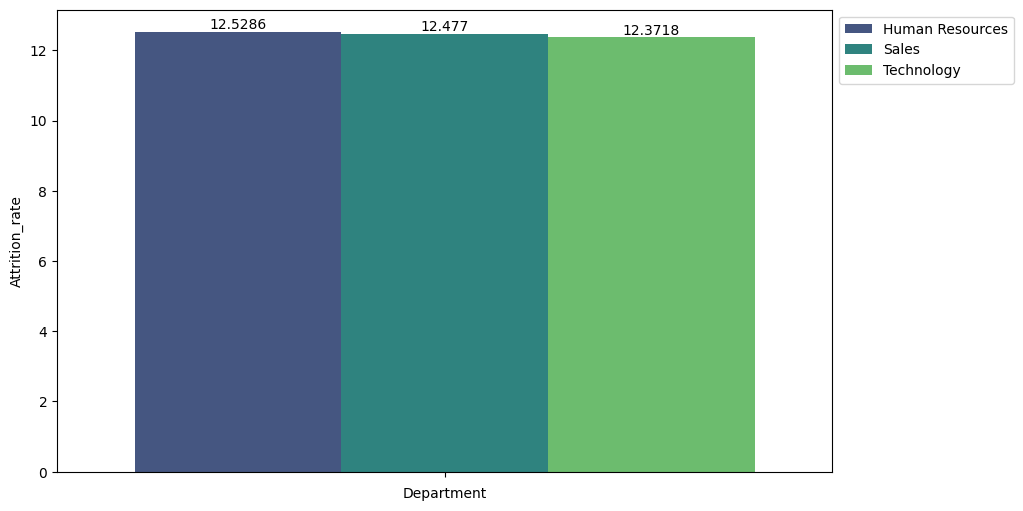

In [112]:
fig,ax=plt.subplots(figsize=(10,6))
sns.barplot(data=attrition_by_dept,y="Attrition_rate",hue="Department",palette="viridis",ax=ax)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.set_xlabel("Department")
for container in ax.containers:
    ax.bar_label(container)

Human Resources has the highest attrition rate at approximately 12.53%, followed by Sales at 12.48% and Technology at 12.37%.

11. Visualize the distribution of Age for employees who have left versus those who have stayed. What do you observe?

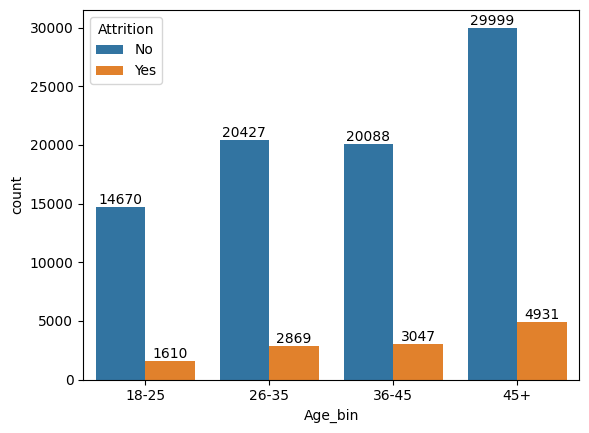

In [113]:
df["Age_bin"]=pd.cut(df["Age"],
                     bins=[18,25,35,45,60],
                     labels=["18-25","26-35","36-45","45+"])
ax=sns.countplot(data=df,x="Age_bin",hue="Attrition")
for container in ax.containers:
    ax.bar_label(container)

In [114]:
attrition_by_age = (
    df.groupby("Age_bin",observed=True)["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
    .reset_index(name="Attrition_Rate")
)

print(attrition_by_age)

  Age_bin  Attrition_Rate
0     45+       14.116805
1   36-45       13.170521
2   26-35       12.315419
3   18-25        9.889435


Attrition increases across the age groups. The 45+ group has the highest attrition rate (approximately 14.12%), while the 18–25 group has the lowest (approximately 9.89%).

12. Create a boxplot to compare the MonthlyIncome of employees who left versus those who stayed. Is there a significant difference?

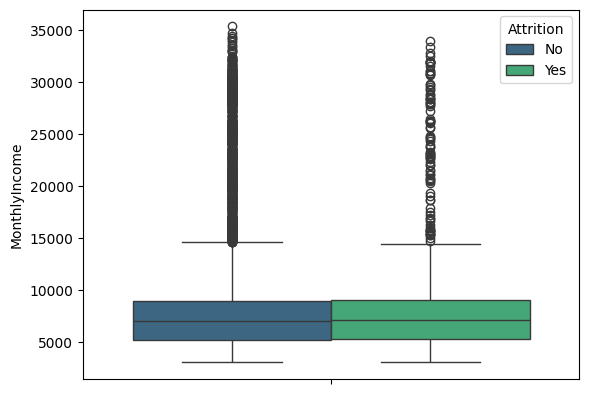

In [115]:
sns.boxplot(data=df,y="MonthlyIncome",hue="Attrition",palette="viridis")
plt.show()

No Significant difference observed

13. Show the relationship between JobSatisfaction and attrition using a count plot or a stacked bar chart.

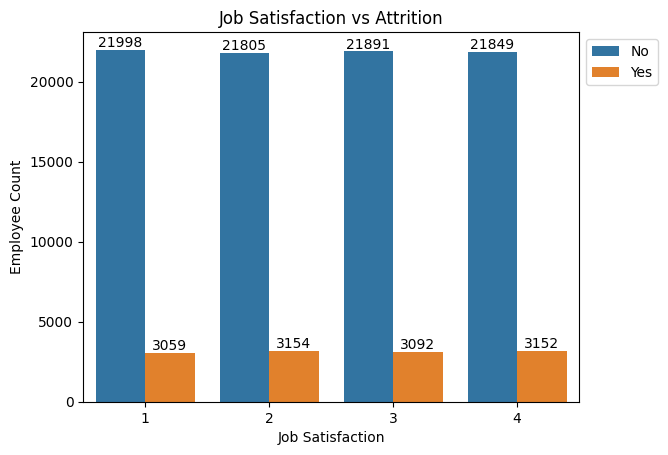

In [116]:
ax = sns.countplot(
    x="JobSatisfaction",
    hue="Attrition",
    data=df
)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
for container in ax.containers:
    ax.bar_label(container)

plt.title("Job Satisfaction vs Attrition")
plt.xlabel("Job Satisfaction")
plt.ylabel("Employee Count")
plt.show()

Job Satisfaction does not appear to have a strong relationship with employee attrition based on this analysis.

14. What are the top 5 JobRoles with the highest number of employees leaving?

In [117]:
top5_roles = (
    df[df["Attrition"] == "Yes"]
    .groupby("JobRole")["Attrition"]
    .count()
    .sort_values(ascending=False)
    .head(5)
    .reset_index(name="Total_Employees")
)

top5_roles

,JobRole,Total_Employees
0,Manager,2112
1,HR Specialist,2096
2,Sales Executive,2093
3,Software Engineer,2081
4,Laboratory Technician,2038


15. Use a heatmap to visualize the correlation between numerical features like Age, MonthlyIncome, YearsAtCompany, PercentSalaryHike, and the satisfaction scores. What are the strongest correlations?

<Axes: >

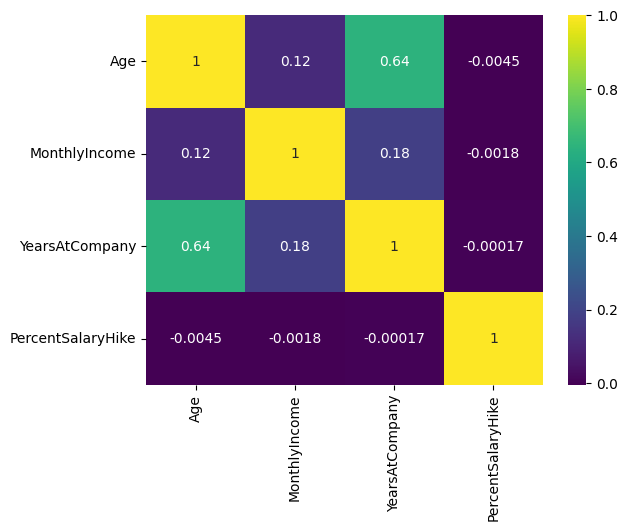

In [118]:

sns.heatmap(df[["Age", "MonthlyIncome", "YearsAtCompany", "PercentSalaryHike"]].corr(),annot=True,cmap="viridis")

Age ↔ YearsAtCompany: 0.64 - Moderately Strong Positive Corelation

16. Analyze the impact of BusinessTravel on attrition by plotting the attrition rate for each travel category

In [119]:
attrition_by_travel = (
    df.groupby("BusinessTravel")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
    .reset_index(name="Attrition_rate")
)
attrition_by_travel

,BusinessTravel,Attrition_rate
0,Non-Travel,12.745451
1,Travel_Rarely,12.328604
2,Travel_Frequently,12.297110


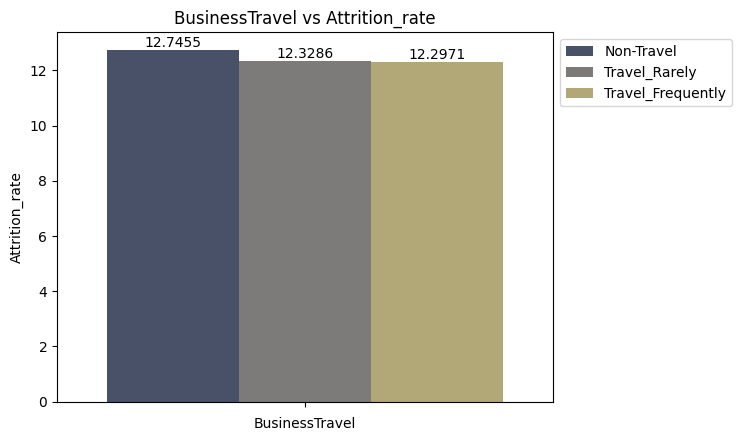

In [120]:
ax=sns.barplot(data=attrition_by_travel,hue="BusinessTravel",y="Attrition_rate",palette="cividis")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
for container in ax.containers:
    ax.bar_label(container)

plt.title("BusinessTravel vs Attrition_rate")
plt.xlabel("BusinessTravel")
plt.ylabel("Attrition_rate")
plt.show()

No significant difference observed

17. Create a TenureInYears column by calculating the difference between DateOfTermination (or the project's current date for active employees) and DateOfHire.

In [121]:
df["Enddate"] = df["DateOfTermination"].fillna(pd.Timestamp("today"))

df["TenureInYears"] = (
    df["Enddate"] - df["DateOfHire"]
).dt.days // 365

df["TenureInYears"]

0        40
1         2
2         4
3         1
4         1
         ..
99995    12
99996     4
99997    33
99998    32
99999     6
Name: TenureInYears, Length: 100000, dtype: int64

19. Create an OverallSatisfaction score by averaging JobSatisfaction, EnvironmentSatisfaction, and RelationshipSatisfaction.

In [122]:
df["OverallSatisfaction"]=df[["JobSatisfaction", "EnvironmentSatisfaction","RelationshipSatisfaction"]].mean(axis=1).round(2)
df["OverallSatisfaction"]

0        3.67
1        2.67
2        2.67
3        2.00
4        1.33
         ... 
99995    1.00
99996    2.67
99997    2.67
99998    1.33
99999    2.00
Name: OverallSatisfaction, Length: 100000, dtype: float64

20. Engineer a PromotionStagnation feature, which could be the ratio of YearsSinceLastPromotion to YearsAtCompany.

In [128]:
df["YearsSinceLastPromotion"]=df["YearsSinceLastPromotion"].fillna(0)

In [135]:
df["PromotionStagnation"]=df["YearsSinceLastPromotion"]/df["YearsAtCompany"]
df["PromotionStagnation"].fillna(0)

0        0.128205
1        0.000000
2        0.000000
3        0.000000
4        0.000000
           ...   
99995    0.090909
99996    0.000000
99997    0.531250
99998    0.937500
99999    0.800000
Name: PromotionStagnation, Length: 100000, dtype: float64

21. Create a IncomeToLevelRatio by dividing MonthlyIncome by JobLevel. Does this ratio differ for employees who leave?

In [138]:
df["IncomeToLevelRatio"] = df["MonthlyIncome"] / df["JobLevel"]
df["IncomeToLevelRatio"]=df["IncomeToLevelRatio"].round(2)

In [139]:
df["IncomeToLevelRatio"]

0        2704.33
1        3768.00
2        3430.00
3        2404.50
4        2114.50
          ...   
99995    2204.00
99996    2242.00
99997    2175.40
99998    4654.00
99999    2178.25
Name: IncomeToLevelRatio, Length: 100000, dtype: float64

In [142]:
df.groupby("Attrition")["IncomeToLevelRatio"].agg(["mean","median"])

,mean,median
Attrition,,
No,2704.881283,2347.0
Yes,2748.137820,2378.0


Employees who left had a slightly higher IncomeToLevelRatio than those who stayed

22. Who are the employees leaving within the first two years of their tenure? Analyze their profile: what are their common departments, job roles, and satisfaction scores?

In [151]:
early_leavers = df[
    (df["Attrition"] == "Yes") &
    (df["TenureInYears"] <= 2)
]

early_leavers.head()

,EmployeeID,Age,Gender,MaritalStatus,DateOfHire,DateOfTermination,Attrition,Department,JobRole,JobLevel,...,WorkLifeBalance,BusinessTravel,DistanceFromHome,EducationField,Age_bin,Enddate,TenureInYears,OverallSatisfaction,PromotionStagnation,IncomeToLevelRatio
48,a4a3da96-b51f-4e2c-87ba-4f4af7327fb4,51,Male,Divorced,2022-10-26,2025-07-19,Yes,Sales,Research Scientist,2,...,2,Travel_Rarely,28,Marketing,45+,2025-07-19,2,1.67,0.0,2798.0
76,a3969b9c-c2e8-45b1-9430-fc69d8244240,22,Male,Divorced,2024-06-24,2026-05-02,Yes,Human Resources,Manager,4,...,4,Non-Travel,25,Technical Degree,18-25,2026-05-02,1,2.67,0.0,1976.5
95,8595a109-3225-44b2-9227-5f5c80887d2e,34,Male,Divorced,2023-08-03,2026-02-22,Yes,Technology,Research Scientist,3,...,1,Travel_Rarely,16,Computer Science,26-35,2026-02-22,2,1.67,0.0,2184.0
144,fa3ff116-9d2e-4efc-80f8-2ad04f2a15b1,20,Male,Married,2023-01-20,2025-05-20,Yes,Technology,Software Engineer,1,...,1,Travel_Frequently,20,CS,18-25,2025-05-20,2,3.00,1.0,3494.0
226,be2a366e-bf53-4be6-b756-a56cdb6a6791,24,Other,Divorced,2023-02-15,2025-11-22,Yes,Technology,HR Specialist,1,...,1,Travel_Frequently,130,Technical Degree,18-25,2025-11-22,2,1.33,1.0,11073.0


In [153]:
Department_wise=early_leavers.groupby("Department").agg(
    Employees=("EmployeeID", "count"),
    AvgJobSatisfaction=("JobSatisfaction", "mean"),
    AvgEnvironmentSatisfaction=("EnvironmentSatisfaction", "mean")
).sort_values("Employees")
Department_wise

,Employees,AvgJobSatisfaction,AvgEnvironmentSatisfaction
Department,,,
Sales,496,2.502016,2.612903
Human Resources,715,2.446154,2.623776
Technology,723,2.496542,2.562932


Among employees who left within their first two years, Technology had the largest number of early leavers (723), followed closely by Human Resources (715), while Sales had fewer (496). Average Job Satisfaction was relatively similar across departments, with HR having the lowest score (2.45). Environment Satisfaction also showed little variation, ranging from 2.56 to 2.62.

In [154]:
Role_wise=early_leavers.groupby("JobRole").agg(
    Employees=("EmployeeID", "count"),
    AvgJobSatisfaction=("JobSatisfaction", "mean"),
    AvgEnvironmentSatisfaction=("EnvironmentSatisfaction", "mean")
).sort_values("Employees", ascending=False)
Role_wise

,Employees,AvgJobSatisfaction,AvgEnvironmentSatisfaction
JobRole,,,
HR Specialist,336,2.473214,2.633929
Sales Executive,333,2.390390,2.615616
Software Engineer,328,2.423780,2.512195
Laboratory Technician,315,2.479365,2.717460
Manager,315,2.596825,2.523810
Research Scientist,307,2.521173,2.586319


Among employees who left within their first two years, HR Specialists had the highest number of early leavers (336), followed closely by Sales Executives (333) and Software Engineers (328). Sales Executives had the lowest average Job Satisfaction (2.39), while Managers had the highest (2.60). Laboratory Technicians reported the highest average Environment Satisfaction (2.72). Overall, satisfaction scores were relatively similar across job roles.

23. Does PercentSalaryHike have an impact on attrition? Group employees by their salary hike percentage and analyze the attrition rate for each group. Are employees who get low hikes more likely to leave?

In [165]:
df["HikeGroup"] = pd.cut(
    df["PercentSalaryHike"],
    bins=[0, 15, 20, 25],
    labels=["Low", "Medium", "High"]
)

In [166]:
hike_attrition = (
    df.groupby("HikeGroup", observed=True)["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .reset_index(name="AttritionRate")
)

hike_attrition

,HikeGroup,AttritionRate
0,Low,12.576426
1,Medium,12.626051
2,High,12.146253


Attrition rates are very similar across salary-hike groups. The Medium group has the highest attrition rate (12.63%), while the High group has the lowest (12.15%). Therefore, employees receiving low salary hikes do not appear to be more likely to leave based on this analysis. The differences are small, suggesting that PercentSalaryHike has little practical impact on attrition.

24. Analyze the effectiveness of managers. Calculate the attrition rate for each ManagerID. Identify the top 5 managers with the highest and lowest attrition rates in their teams.

In [168]:
df["AttritionFlag"] = df["Attrition"].map({"No":0, "Yes":1})
manager_stats = (
    df.groupby("ManagerID")
    .agg(
        TeamSize=("EmployeeID", "count"),
        AttritionRate=("AttritionFlag", "mean")
    )
    .reset_index()
)
manager_stats["AttritionRate"] = manager_stats["AttritionRate"] * 100
manager_stats.head()

,ManagerID,TeamSize,AttritionRate
0,0002dac3-02fa-43b4-b551-e176b17e9ab7,17,17.647059
1,00037405-bd55-49e9-aafe-8a3e7daa2fe2,18,5.555556
2,00266a06-2987-4c70-9275-5634984fcbca,22,9.090909
3,002a399d-5eb2-4013-be46-335536cdd3bd,20,5.000000
4,00335129-3ef5-409e-bb73-b79e2392563a,12,8.333333


In [169]:
manager_stats_filtered = manager_stats[manager_stats["TeamSize"] >= 3]
top_5_high = manager_stats_filtered.sort_values(
    by="AttritionRate",
    ascending=False
).head(5)

In [170]:
top_5_high

,ManagerID,TeamSize,AttritionRate
784,28dd0e5e-6aaa-4504-b7fd-1b4276b1b61f,7,71.428571
1608,552f3b99-7ab1-4df1-b91c-9b8d33477bcf,12,50.000000
187,09a03dc6-9ac5-4a8b-825f-23ad9f262aff,10,50.000000
3111,a278becb-b9bb-4dbd-ad19-86dbb8c5e142,8,50.000000
115,0639b911-4fdf-491a-80a0-2d804d04a4c1,15,46.666667


In [171]:
top_5_low = manager_stats_filtered.sort_values(
    by="AttritionRate",
    ascending=True
).head(5)

In [172]:
top_5_low

,ManagerID,TeamSize,AttritionRate
3480,b541008a-7d93-422c-9a6b-c477770ba32e,19,0.0
4634,edeecd02-4d5d-4654-8b20-ca4838ad8607,17,0.0
3689,bfc46ca6-8e42-459f-8b90-88b98384aadc,13,0.0
1347,466815d2-eabb-4d01-9e91-9d646c3b75ee,9,0.0
3675,bf2cf671-3be8-4134-b836-deb59a0ea1e9,13,0.0


25. Is there a "burnout" profile? Analyze employees who have a high HourlyRate but low WorkLifeBalance scores. What is their attrition rate compared to the average?

In [175]:
high_rate_threshold = df["HourlyRate"].quantile(0.75)
burnout_group = df[
    (df["HourlyRate"] >= high_rate_threshold) &
    (df["WorkLifeBalance"] <= 2)
]
burnout_attrition_rate = (
    burnout_group["Attrition"]
    .value_counts(normalize=True)["Yes"] * 100
)
overall_attrition_rate = (
    df["Attrition"]
    .value_counts(normalize=True)["Yes"] * 100
)
print(burnout_attrition_rate,overall_attrition_rate)

12.940987812700449 12.457


No significant difference oberved

26. Compare the PerformanceRating of employees who left versus those who stayed. Is the company losing its high performers or low performers?

<Axes: xlabel='Attrition', ylabel='PerformanceRating'>

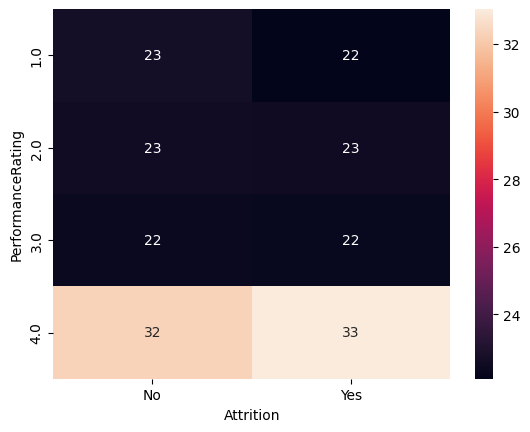

In [179]:
sns.heatmap(pd.crosstab(
    df["PerformanceRating"],
    df["Attrition"],
    normalize="columns"
) * 100,annot=True)

There is no clear evidence that the company is disproportionately losing either high or low performers. Attrition rates are nearly identical across performance ratings, although the highest-performing group has a marginally higher attrition rate

27. How does DistanceFromHome impact attrition for different JobRoles? For example, is a long commute more likely to cause a Sales Executive to leave compared to a Research Scientist?

In [186]:
df["DistanceGroup"] = pd.cut(
    df["DistanceFromHome"],
    bins=[0,5,15,30,100],
    labels=["0-5 (Near)", "6-15 (Moderate)", "16-30 (Far)", "30+ (Very Far)"]
)


In [187]:
role_distance_attrition = (
    df.groupby(
        ["JobRole", "DistanceGroup"],
        observed=True
    )["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="AttritionRate")
)

role_distance_attrition

,JobRole,DistanceGroup,AttritionRate
0,HR Specialist,0-5 (Near),12.815750
1,HR Specialist,6-15 (Moderate),12.105452
2,HR Specialist,16-30 (Far),12.909135
3,HR Specialist,30+ (Very Far),14.285714
4,Laboratory Technician,0-5 (Near),12.636166
5,Laboratory Technician,6-15 (Moderate),12.188919
6,Laboratory Technician,16-30 (Far),11.953804
7,Laboratory Technician,30+ (Very Far),12.162162
8,Manager,0-5 (Near),11.948998
9,Manager,6-15 (Moderate),12.627255


In [189]:
pivot = role_distance_attrition.pivot(
    index="JobRole",
    columns="DistanceGroup",
    values="AttritionRate"
)
pivot

DistanceGroup,0-5 (Near),6-15 (Moderate),16-30 (Far),30+ (Very Far)
JobRole,,,,
HR Specialist,12.815750,12.105452,12.909135,14.285714
Laboratory Technician,12.636166,12.188919,11.953804,12.162162
Manager,11.948998,12.627255,12.878880,16.049383
Research Scientist,12.332838,12.244898,12.458897,5.333333
Sales Executive,12.397577,12.287234,12.551540,14.285714
Software Engineer,12.855007,12.381473,12.639225,9.876543


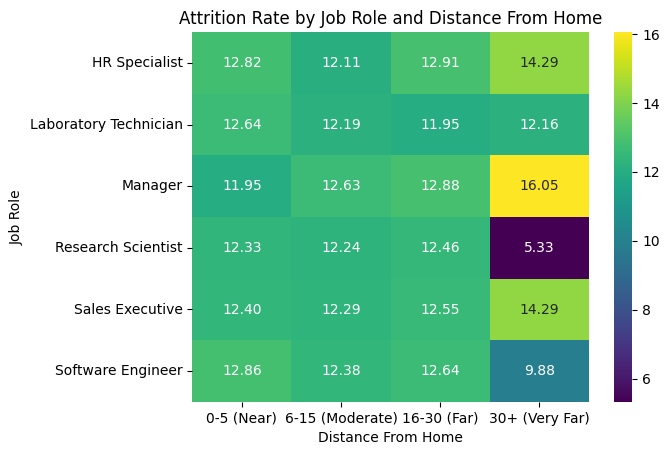

In [190]:
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Attrition Rate by Job Role and Distance From Home")
plt.xlabel("Distance From Home")
plt.ylabel("Job Role")
plt.show()

Distance from home appears to have different associations with attrition across job roles. Managers have the highest attrition rate among employees living 30+ units away (16.05%), while Sales Executives also show elevated attrition (14.29%). In contrast, Research Scientists have a much lower attrition rate in the 30+ group (5.33%). Therefore, the relationship between commuting distance and attrition appears to vary by job role, with long commutes potentially being more associated with attrition for Sales Executives and Managers.

28. Build a profile of the "ideal loyal employee" based on the characteristics of employees with the longest tenure and 'No' for attrition.

In [193]:
loyal = df[
    (df["Attrition"] == "No") &
    (df["TenureInYears"] == df["TenureInYears"].quantile(0.90))
]
profile = {
    "Department": loyal["Department"].mode()[0],
    "JobRole": loyal["JobRole"].mode()[0],
    "BusinessTravel": loyal["BusinessTravel"].mode()[0],
    "MaritalStatus": loyal["MaritalStatus"].mode()[0],
    "AvgAge": loyal["Age"].mean(),
    "AvgIncome": loyal["MonthlyIncome"].mean(),
    "AvgJobSatisfaction": loyal["JobSatisfaction"].mean(),
    "AvgEnvironmentSatisfaction": loyal["EnvironmentSatisfaction"].mean(),
    "AvgWorkLifeBalance": loyal["WorkLifeBalance"].mean(),
    "AvgJobLevel": loyal["JobLevel"].mean()
}

profile

{'Department': 'Human Resources',
 'JobRole': 'HR Specialist',
 'BusinessTravel': 'Travel_Frequently',
 'MaritalStatus': 'Single',
 'AvgAge': np.float64(50.75941230486685),
 'AvgIncome': np.float64(7801.6905417814505),
 'AvgJobSatisfaction': np.float64(2.5280073461891646),
 'AvgEnvironmentSatisfaction': np.float64(2.524334251606979),
 'AvgWorkLifeBalance': np.float64(2.519742883379247),
 'AvgJobLevel': np.float64(2.911845730027548)}

In this profile, they are predominantly HR Specialists in Human Resources, travel frequently, and are single. They have an average age of approximately 51 years, monthly income of about 7,802, and JobLevel of 2.91. Their Job Satisfaction, Environment Satisfaction, and Work-Life Balance scores are all around 2.5, indicating moderate satisfaction levels.

29. Synthesize your findings to identify the top 3-5 drivers of attrition at InnovateTech.

The top potential drivers of attrition at InnovateTech are age/life-stage differences, long commuting distances for certain job roles, substantial variation in manager/team-level attrition, income relative to job level, and early-tenure employee retention. However, several commonly suspected factors—such as BusinessTravel, PerformanceRating, PercentSalaryHike, and the defined burnout profile—showed little or no meaningful evidence of being major attrition drivers.

30. Based on your entire analysis, formulate three concrete, data-driven recommendations for InnovateTech's leadership team to help them reduce employee attrition.

InnovateTech should prioritize three areas: (1) targeted retention initiatives for long-distance employees in high-risk roles such as Managers and Sales Executives, (2) manager-level interventions for teams with unusually high attrition, and (3) a structured early-tenure retention program for employees during their first two years